In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.stats import entropy

In [ ]:
# Downloading the dataset
# Clone the entire repo
# !git clone https://github.com/nikhilvenkatkumsetty/TrashBox

# Access files inside
import os
os.listdir("REPO/")

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import entropy

dataset_path = "TrashBox_train_set"

records = []

for label in os.listdir(dataset_path):

    folder = os.path.join(dataset_path,label)

    if os.path.isdir(folder):

        for file in os.listdir(folder):

            path = os.path.join(folder,file)

            try:

                img = cv2.imread(path)

                if img is None:
                    continue

                h,w = img.shape[:2]

                gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

                brightness = np.mean(gray)
                contrast = np.std(gray)

                edges = cv2.Canny(gray,100,200)
                edge_density = np.sum(edges>0)/edges.size

                blur = cv2.Laplacian(gray,cv2.CV_64F).var()

                hist = cv2.calcHist([gray],[0],None,[256],[0,256])
                img_entropy = entropy(hist.ravel()+1)

                file_size = os.path.getsize(path)/1024

                records.append({
                    "label":label,
                    "width":w,
                    "height":h,
                    "brightness":brightness,
                    "contrast":contrast,
                    "edge_density":edge_density,
                    "blur":blur,
                    "entropy":img_entropy,
                    "file_size":file_size
                })

            except:
                pass

df = pd.DataFrame(records)

df["aspect_ratio"] = df.width/df.height

print("Images loaded:",len(df))
df.head()

Images loaded: 14279


,label,width,height,brightness,contrast,edge_density,blur,entropy,file_size,aspect_ratio
0,cardboard,613,613,149.521131,76.572272,0.064827,331.846770,5.247396,765.382812,1.000000
1,cardboard,770,450,168.186193,53.325762,0.063079,620.221423,5.079692,54.491211,1.711111
2,cardboard,512,384,109.605108,66.247007,0.031514,266.320913,5.206923,18.492188,1.333333
3,cardboard,360,240,193.496528,41.345512,0.088924,727.470683,4.892174,32.784180,1.500000
4,cardboard,390,280,227.403864,36.457790,0.033800,1189.249835,3.851235,13.644531,1.392857


In [4]:
df = df.dropna()

df = df[df.width > 0]
df = df[df.height > 0]

df["aspect_ratio"] = df.width / df.height

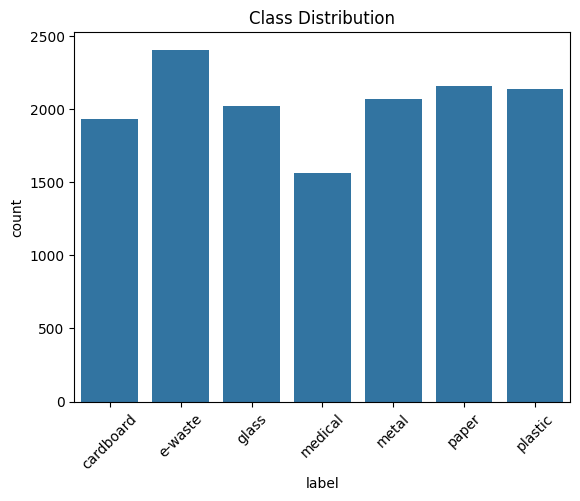

In [5]:
#Class distribution - dataset imbalance
sns.countplot(data=df,x="label")
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

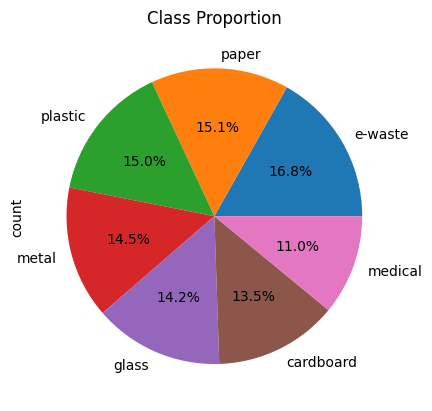

In [6]:
#Class proportions - dataset composition
df.label.value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Class Proportion")
plt.show()

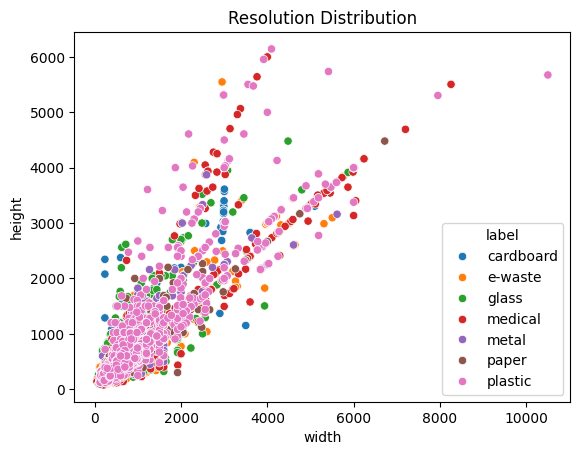

In [7]:
#Resolution scatter - camera resolution diversity
sns.scatterplot(x=df.width,y=df.height,hue=df.label)
plt.title("Resolution Distribution")
plt.show()

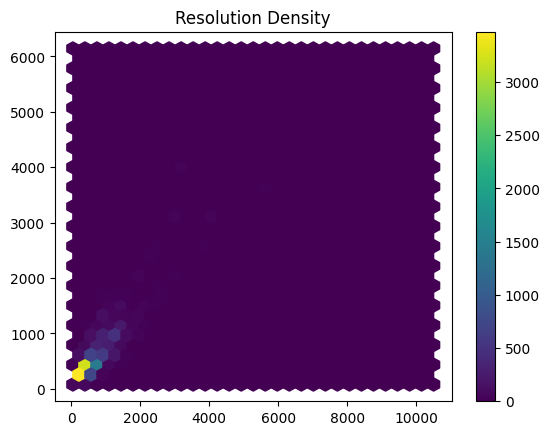

In [8]:
#Resolution density - most common image sizes
plt.hexbin(df.width,df.height,gridsize=30)
plt.colorbar()
plt.title("Resolution Density")
plt.show()

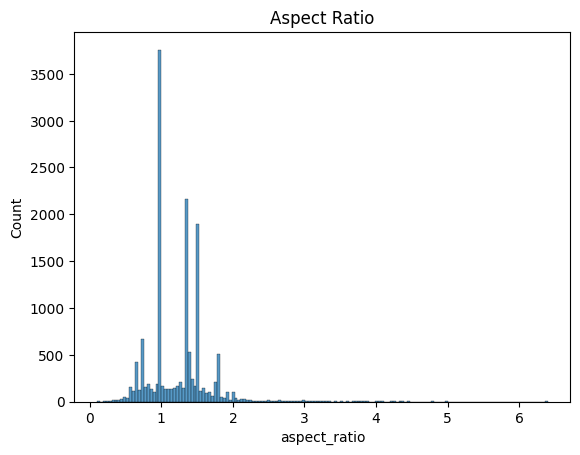

In [9]:
#Aspect ratio distribution - image framing patterns
sns.histplot(df.aspect_ratio)
plt.title("Aspect Ratio")
plt.show()

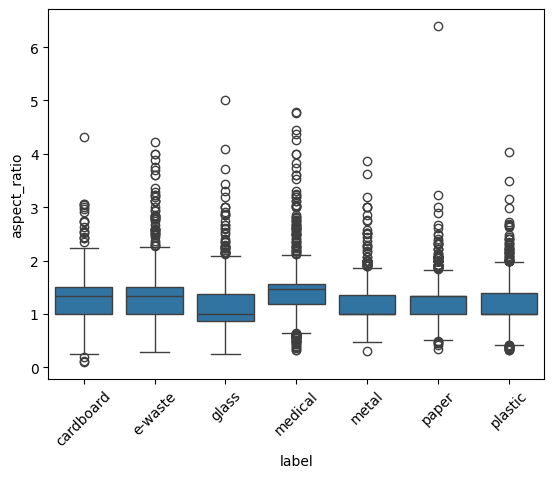

In [10]:
#Aspect ratio by class - whether objects appear in specific shapes
sns.boxplot(x="label",y="aspect_ratio",data=df)
plt.xticks(rotation=45)
plt.show()

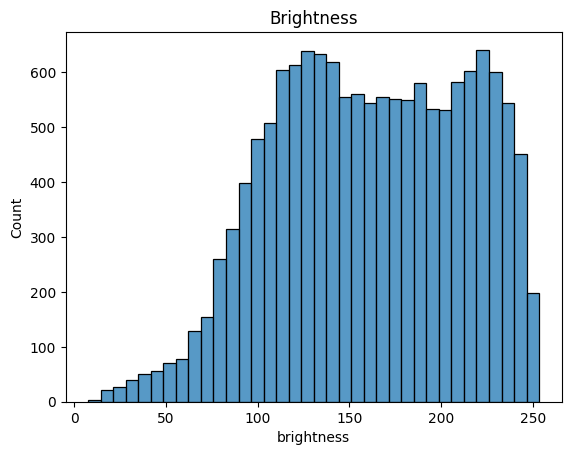

In [11]:
#Brightness distribution - lighting conditions
sns.histplot(df.brightness)
plt.title("Brightness")
plt.show()

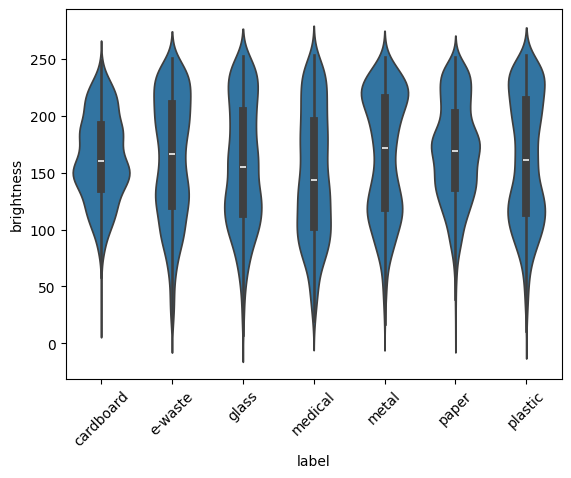

In [12]:
#Brightness by class - material reflectivity differences
sns.violinplot(x="label",y="brightness",data=df)
plt.xticks(rotation=45)
plt.show()

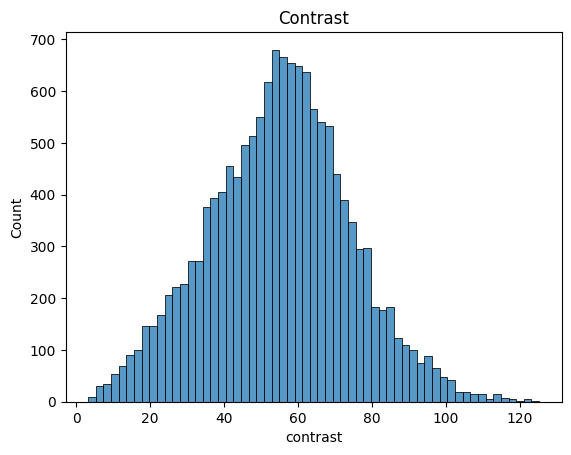

In [13]:
#Contrast distribution - texture strength
sns.histplot(df.contrast)
plt.title("Contrast")
plt.show()

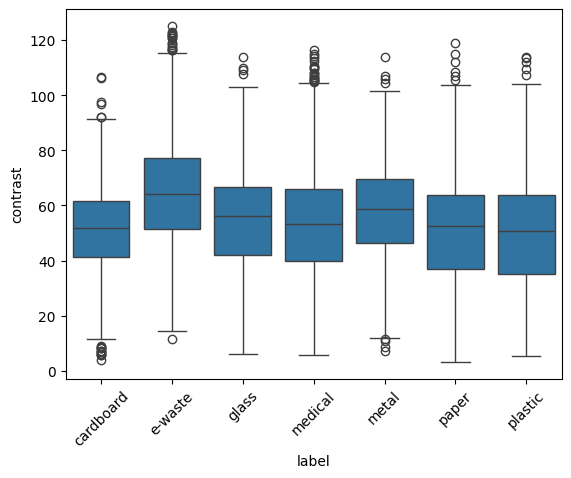

In [14]:
#Contrast by class - texture differences between materials
sns.boxplot(x="label",y="contrast",data=df)
plt.xticks(rotation=45)
plt.show()

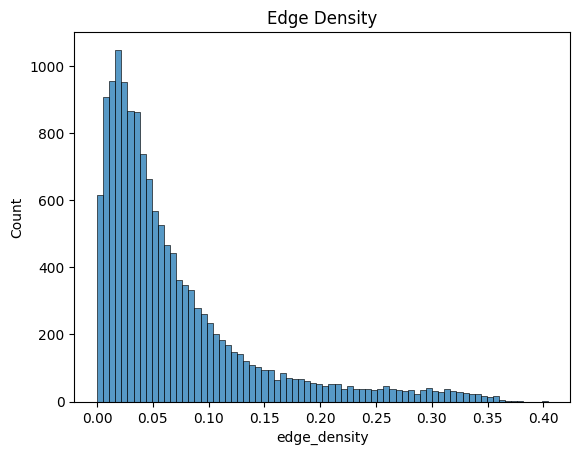

In [15]:
#Edge density distribution - structural complexity
sns.histplot(df.edge_density)
plt.title("Edge Density")
plt.show()

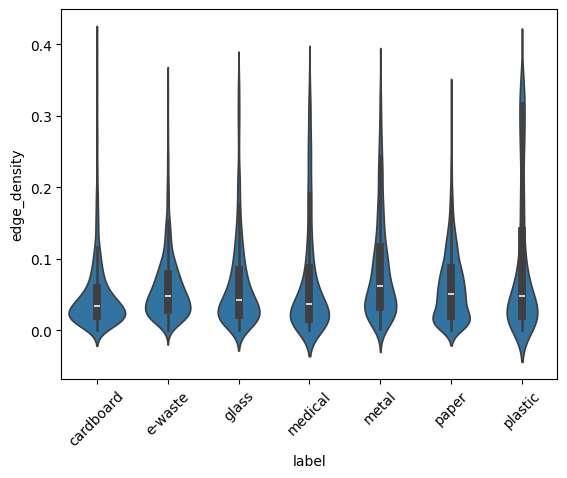

In [16]:
#Edge density by class - object boundary complexity
sns.violinplot(x="label",y="edge_density",data=df)
plt.xticks(rotation=45)
plt.show()

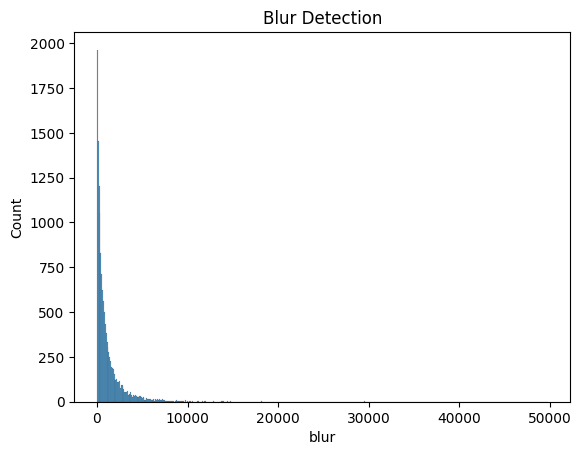

In [17]:
#Blur distribution - dataset quality
sns.histplot(df.blur)
plt.title("Blur Detection")
plt.show()

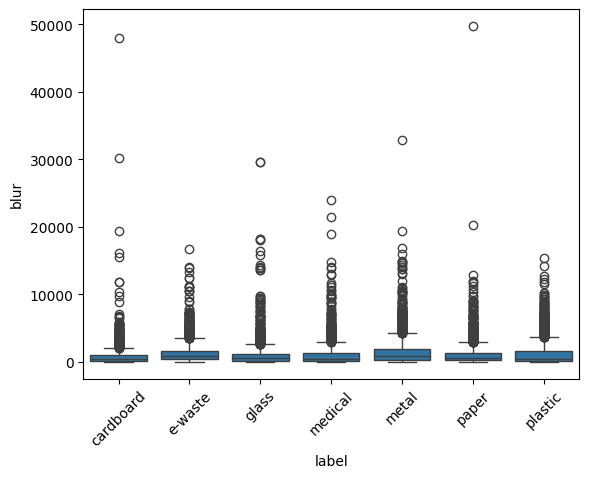

In [18]:
#Blur by class - which classes contain blurry images
sns.boxplot(x="label",y="blur",data=df)
plt.xticks(rotation=45)
plt.show()

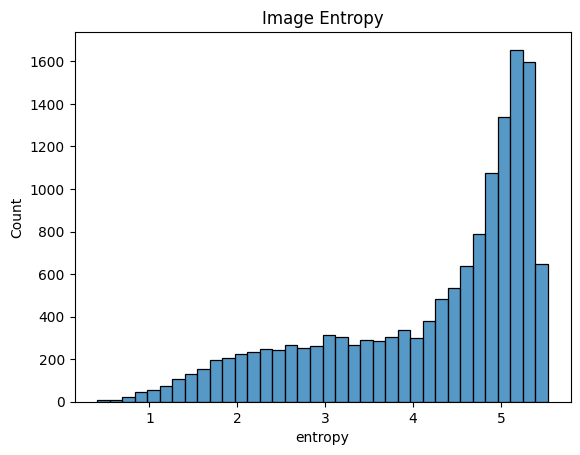

In [19]:
#Image entropy distribution - image complexity
sns.histplot(df.entropy)
plt.title("Image Entropy")
plt.show()

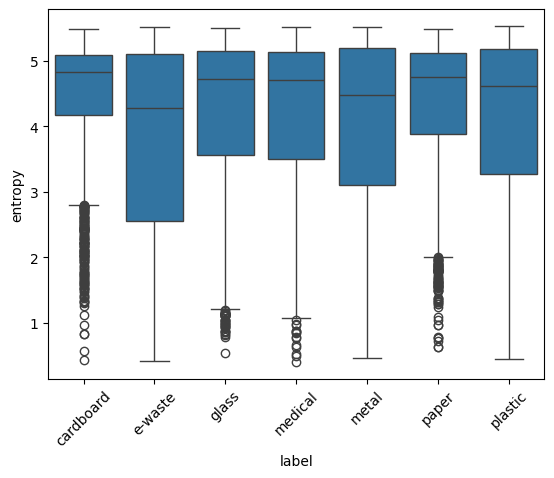

In [20]:
#Entropy by class - complexity differences among materials
sns.boxplot(x="label",y="entropy",data=df)
plt.xticks(rotation=45)
plt.show()

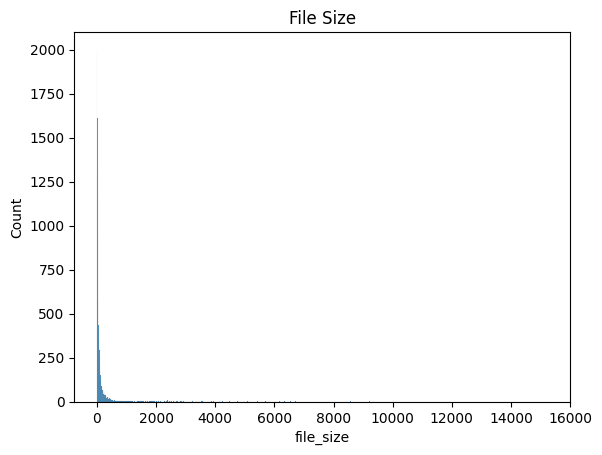

In [ ]:
#File size distribution - compression differences
sns.histplot(df.file_size)
plt.title("File Size")
plt.show()

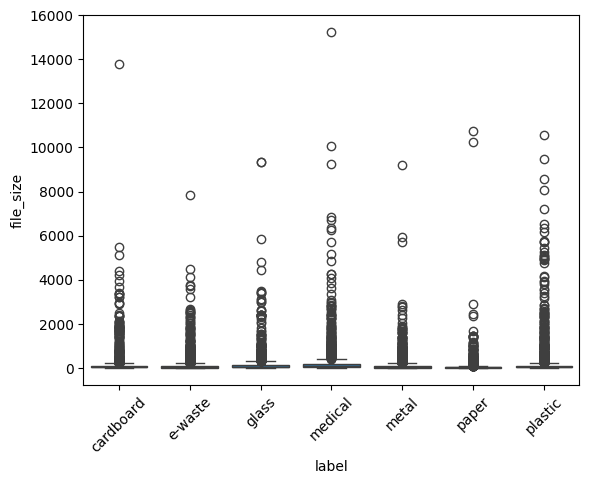

In [ ]:
#File size by class - compression variation between classes
sns.boxplot(x="label",y="file_size",data=df)
plt.xticks(rotation=45)
plt.show()

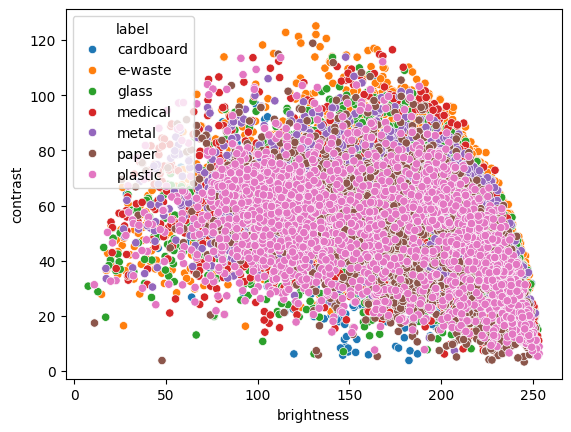

In [ ]:
#Brightness vs contrast - lighting vs texture relationship
sns.scatterplot(x="brightness",y="contrast",hue="label",data=df)
plt.show()

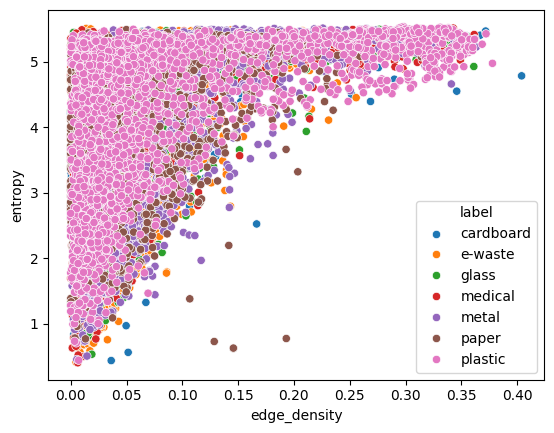

In [24]:
#Edge density vs entropy - structure vs complexity
sns.scatterplot(x="edge_density",y="entropy",hue="label",data=df)
plt.show()

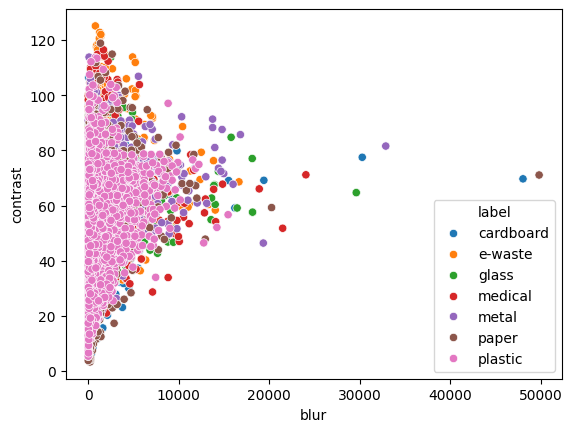

In [ ]:
#Blur vs contrast - blur effect on texture
sns.scatterplot(x="blur",y="contrast",hue="label",data=df)
plt.show()

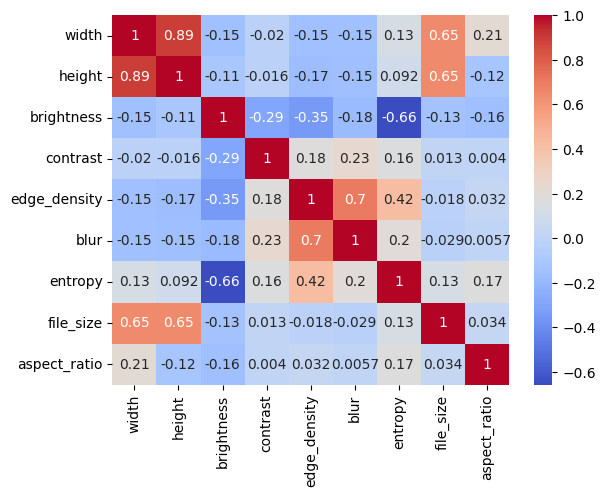

In [27]:
#Feature correlation heatmap - relationships between features
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

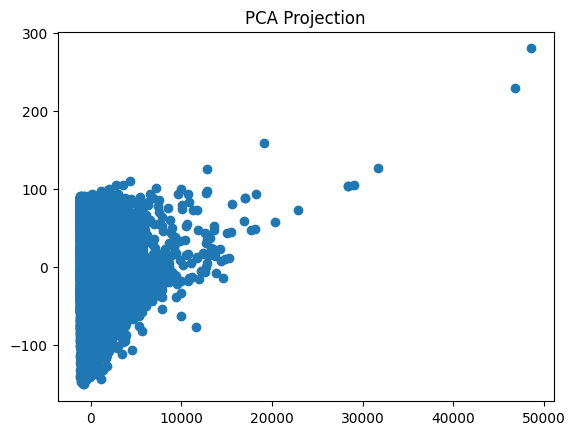

In [28]:
#PCA visualization - feature separability
from sklearn.decomposition import PCA

features=df[['brightness','contrast','edge_density','blur','entropy']]

X=PCA(n_components=2).fit_transform(features)

plt.scatter(X[:,0],X[:,1])
plt.title("PCA Projection")
plt.show()

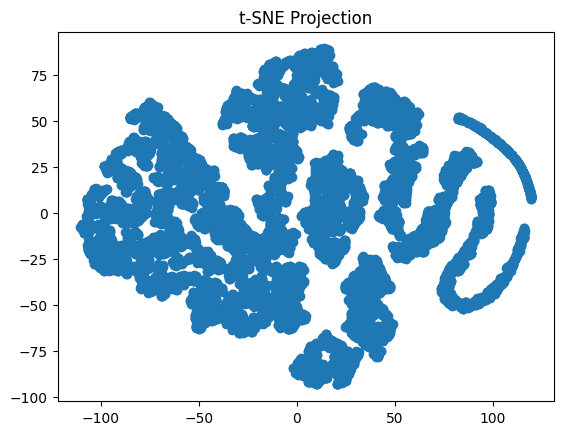

In [29]:
#t-SNE visualization - clustering of waste types
from sklearn.manifold import TSNE

X=TSNE(n_components=2).fit_transform(features)

plt.scatter(X[:,0],X[:,1])
plt.title("t-SNE Projection")
plt.show()

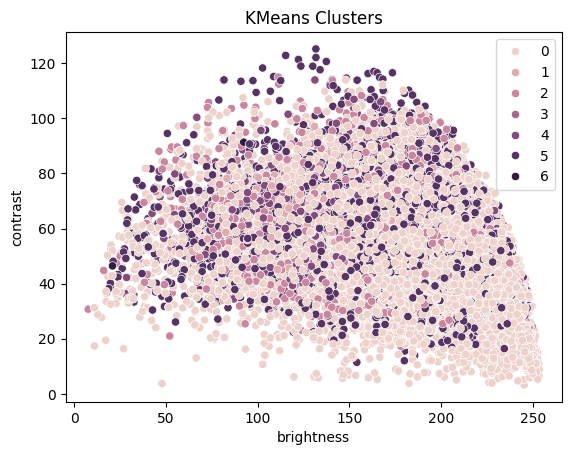

In [30]:
#KMeans clustering - natural grouping of materials
from sklearn.cluster import KMeans

clusters=KMeans(n_clusters=7).fit_predict(features)

sns.scatterplot(x=features.iloc[:,0],y=features.iloc[:,1],hue=clusters)
plt.title("KMeans Clusters")
plt.show()

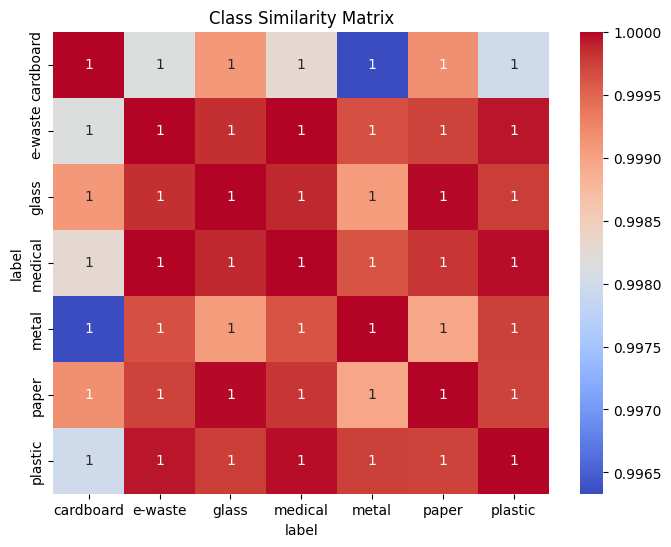

In [31]:
#Class Similarity Matrix - Understand how visually similar the classes are.
from sklearn.metrics.pairwise import cosine_similarity

features = ['brightness','contrast','edge_density','blur','entropy']

class_means = df.groupby('label')[features].mean()

similarity = cosine_similarity(class_means)

similarity_df = pd.DataFrame(similarity,
                             index=class_means.index,
                             columns=class_means.index)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm")
plt.title("Class Similarity Matrix")
plt.show()

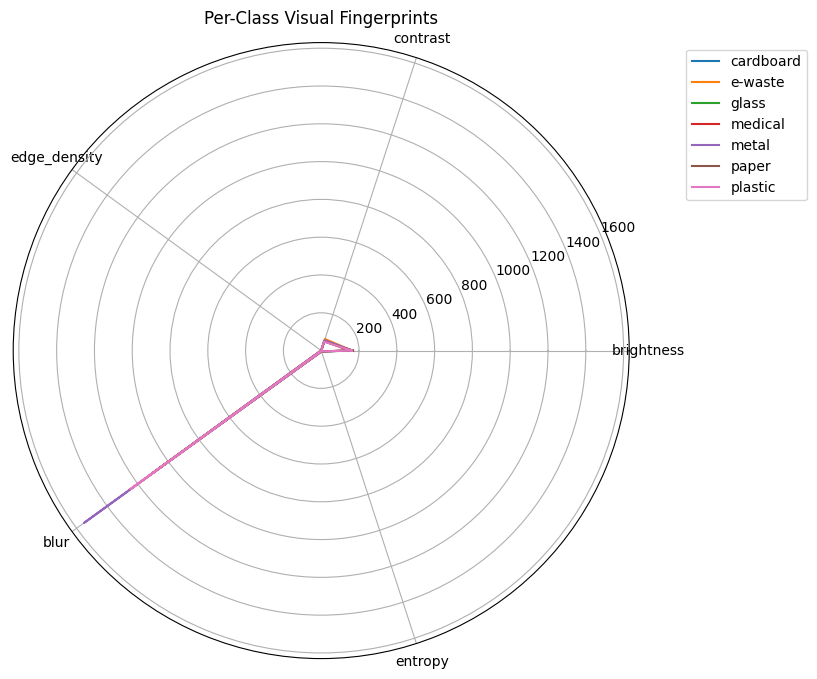

In [ ]:
#Per-Class Visual Fingerprints radar chart - Show the feature signature of each class.
import numpy as np

features = ['brightness','contrast','edge_density','blur','entropy']

class_means = df.groupby('label')[features].mean()

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(8,8))

for label,row in class_means.iterrows():
    
    values=row.values
    values=np.concatenate((values,[values[0]]))
    
    plt.polar(angles,values,label=label)

plt.xticks(angles[:-1],labels)
plt.title("Per-Class Visual Fingerprints")
plt.legend(bbox_to_anchor=(1.3,1))
plt.show()

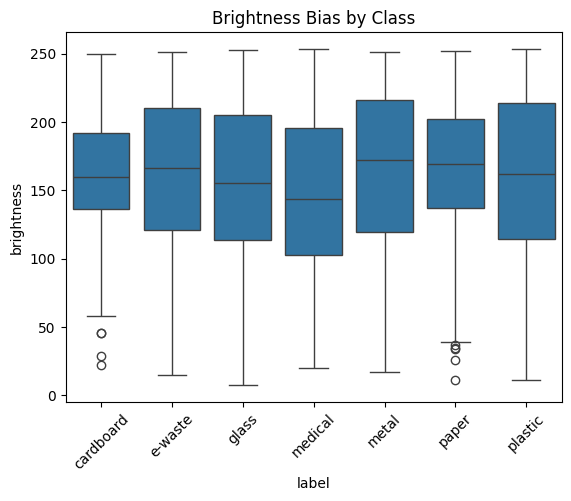

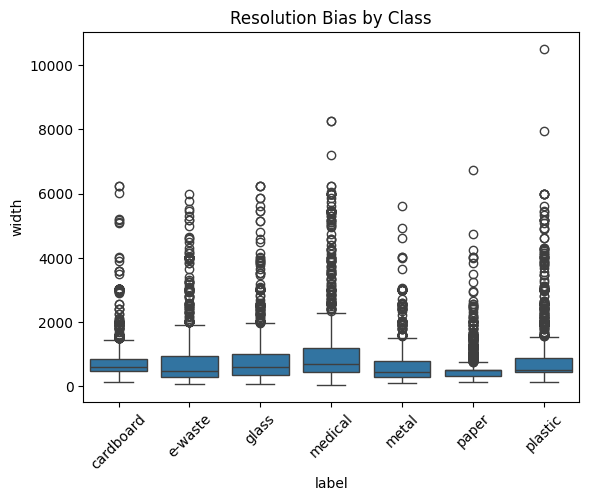

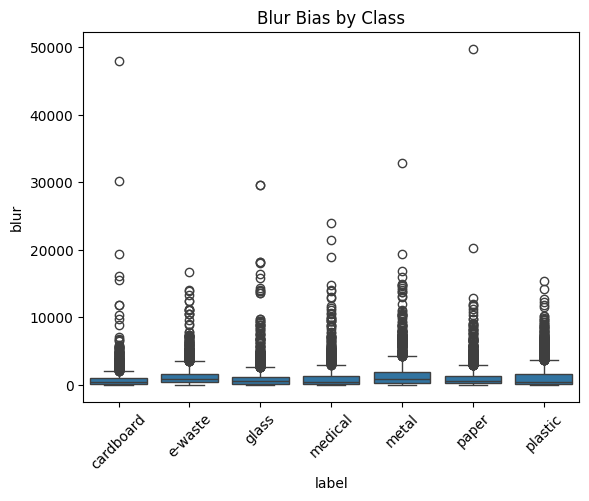

In [33]:
#Dataset Bias Detection - Detect if certain classes dominate certain conditions.

#brightness bias
sns.boxplot(x="label",y="brightness",data=df)
plt.xticks(rotation=45)
plt.title("Brightness Bias by Class")
plt.show()

#resolution bias
sns.boxplot(x="label",y="width",data=df)
plt.xticks(rotation=45)
plt.title("Resolution Bias by Class")
plt.show()

#blur bias
sns.boxplot(x="label",y="blur",data=df)
plt.xticks(rotation=45)
plt.title("Blur Bias by Class")
plt.show()